In [1]:
!ls ../../data/cableflat-3buttons/episode000033/

images	rawdata.h5  states.npz


In [2]:
import pandas as pd
import numpy as np
from PIL import Image
import os
import pathlib
import matplotlib.pyplot as plt
import h5py

from ipywidgets import interact
from agent.model.qwen import QwenClient

In [3]:
qc = QwenClient()

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

/home/albertxu/miniconda3/envs/torch/lib/python3.14/site-packages/torch/cuda/__init__.py:1074: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

In [6]:
def get_frame(base, tt):
    base = pathlib.Path(base)
    with h5py.File(base / 'rawdata.h5', 'r') as f:
        its = np.array(f['camera_obs/time'])
        tix = np.argmin(np.abs(its - tt))
        frame = Image.fromarray(f['camera_obs/image_bgr'][tix][...,::-1])
    return [frame]

In [64]:
test_cases = [
    get_frame('../../data/debug-qwen/episode000003/', 0), # open, on cardboard
    get_frame('../../data/debug-qwen/episode000003/', 60), # open, obscured
    get_frame('../../data/debug-qwen/episode000002/', 10), # out of frame
    get_frame('../../data/debug-qwen/episode000002/', 30), # closed, held
    get_frame('../../data/debug-qwen/episode000003/', 30), # closed, above new switch
    get_frame('../../data/debug-qwen/episode000002/', 50), # plugging
    get_frame('../../data/debug-qwen/episode000002/', 60), # plugged
    get_frame('../../data/debug-qwen/episode000002/', 90), # dropped
    get_frame('../../data/debug-qwen/episode000003/', 20), # plugging & visible
    get_frame('../../data/debug-qwen/episode000003/', 36), # plugging & visible
]

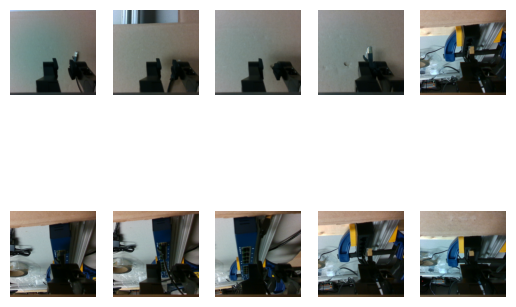

In [65]:
for i in range(min(len(test_cases), 10)):
    plt.subplot(2,5,i+1)
    plt.imshow(test_cases[i][0])
    plt.axis('off')

In [72]:
f1 = get_frame('../../data/debug-qwen/episode000002/', 40)
qc.score_state(f1)

{'the cable is up near the gripper against the plain workspace': 0.6164161982022787,
 'the cable is over at the network switch': 0.37387533765206094,
 'the cable is not visible in the frame': 0.0097084641456604}

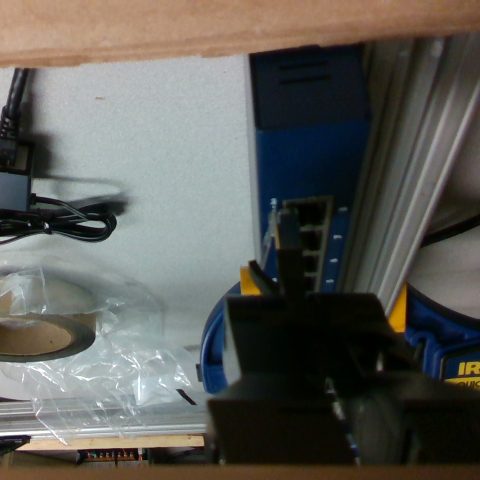

In [73]:
f1[0]

In [28]:
# Check from rawdata
# basedir = pathlib.Path('../../data/cableflat-3buttons/episode000033/')
basedir = pathlib.Path('../../data/debug-qwen/episode000003/')
with h5py.File(basedir / 'rawdata.h5', 'r') as f:
    print(f['robot_obs'].keys())
    print(f['gripper_obs'].keys())
    actual_force = np.array(f['robot_obs/actual_force'])
    fts = np.array(f['robot_obs/time'])

    nim = len(f['camera_obs/image_bgr'])
    its = np.array(f['camera_obs/time'])

    ixs = np.arange(0, nim, 50)
    ims = [Image.fromarray(f['camera_obs/image_bgr'][ix][...,::-1]) for ix in ixs]

print(nim, actual_force[0])

<KeysViewHDF5 ['actual_force', 'actual_pose', 'time']>
<KeysViewHDF5 ['gripper_force', 'gripper_width', 'time']>
1769 [ 0.16649181  0.29770195  0.54968149 -0.00763209  0.02304189  0.00759683]


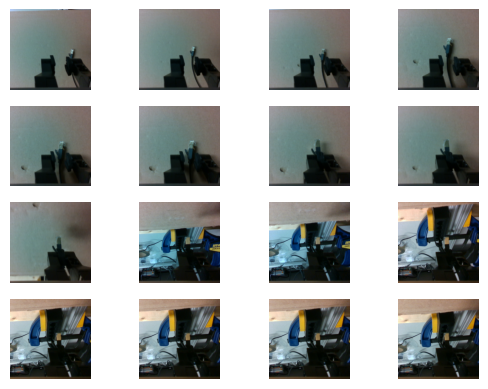

In [29]:
for i in range(min(len(ims), 16)):
    plt.subplot(4,4,i+1)
    plt.imshow(ims[i])
    plt.axis('off')

In [31]:
def get_frames(tt):
    tix = np.argmin(np.abs(its - tt))
    with h5py.File(basedir / 'rawdata.h5', 'r') as f:
        ixs = np.arange(tix - 7, tix + 1)
        frames = [Image.fromarray(f['camera_obs/image_bgr'][ix][...,::-1]) for ix in ixs]
    return frames


In [52]:
tobs = 15
frames = get_frames(tobs)
qc.score_state(frames)

{'the cable is up near the gripper against the plain workspace': 0.24025167524814606,
 'the cable is over at the network switch': 0.7400272488594055,
 'the cable is not visible in the frame': 0.019721059128642082}

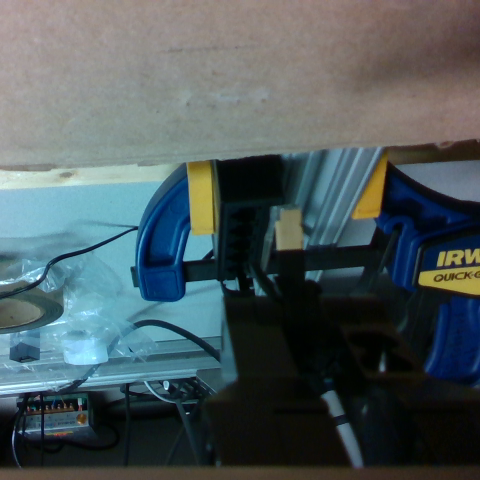

In [53]:
frames[-1]

In [54]:
frames0 = get_frames(0)
frames10 = get_frames(10)
frames30 = get_frames(30)
frames60 = get_frames(60)
frames90 = get_frames(90)

In [47]:
frames30 = get_frames(30)
frames31 = get_frames(31)
frames35 = get_frames(35)
frames45 = get_frames(45)
